In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("health_study_dataset.csv")
df.head(10)

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0
5,6,46,F,167.6,68.6,153.8,4.91,No,0
6,7,73,M,185.8,83.0,150.0,5.92,No,0
7,8,61,F,168.1,51.5,134.8,5.13,Yes,0
8,9,42,M,182.3,81.7,141.0,4.02,No,0
9,10,58,F,157.1,67.3,159.8,5.38,No,0


In [12]:
import numpy as np
import pandas as pd
num_cols=["age", "weight", "height", "systolic_bp", "cholesterol"]
rows = []
for c in num_cols:
    x = df[c].dropna().to_numpy()
    rows.append({
        "variabel": c,
        "n": int(x.size),
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
    })

desc_table = pd.DataFrame(rows).set_index("variabel")
desc_table_rounded = desc_table.round({"mean":2, "median":2, "min":2, "max":2})
desc_table_rounded

,n,mean,median,min,max
variabel,,,,,
age,800,49.43,50.00,18.0,90.00
weight,800,73.41,73.20,33.7,114.40
height,800,171.85,171.35,144.4,200.40
systolic_bp,800,149.18,149.40,106.8,185.90
cholesterol,800,4.93,4.97,2.5,7.88


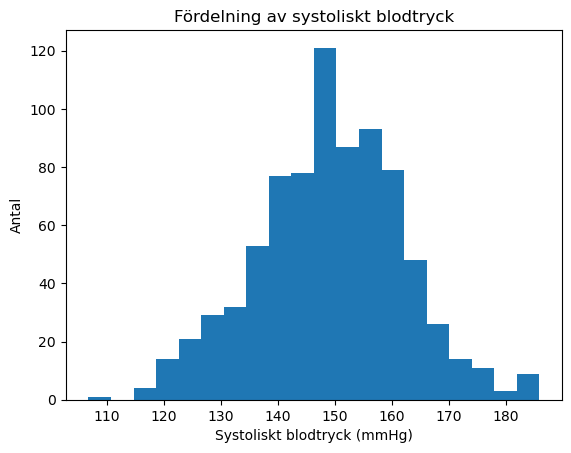

In [13]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df["systolic_bp"].dropna(), bins=20)
plt.title("Fördelning av systoliskt blodtryck")
plt.xlabel("Systoliskt blodtryck (mmHg)")
plt.ylabel("Antal")
plt.show()

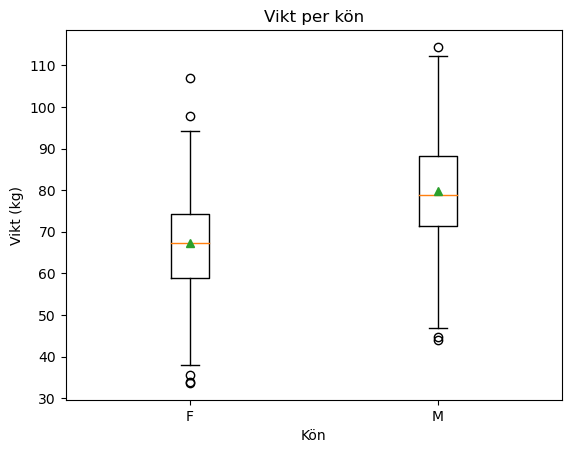

In [14]:
labels = sorted(df["sex"].dropna().astype(str).unique())
data = [df.loc[df["sex"].astype(str)==lab, "weight"].dropna().to_numpy() for lab in labels]

plt.figure()
plt.boxplot(data, labels=labels, showmeans=True)
plt.title("Vikt per kön")
plt.xlabel("Kön")
plt.ylabel("Vikt (kg)")
plt.show()

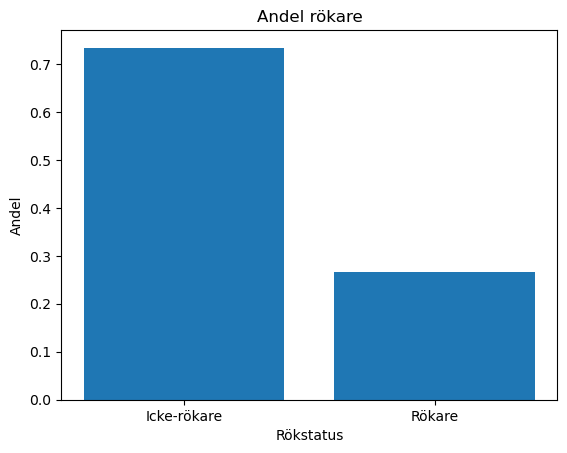

In [15]:
def to_binary(series):
    s = series.astype(str).str.strip().str.lower()
    true_vals = {"1","true","yes","y","t","smoker","ja"}
    return s.isin(true_vals).astype(int)

smoker_bin = to_binary(df["smoker"])
counts = smoker_bin.value_counts().sort_index()
props = counts / counts.sum()

plt.figure()
plt.bar(["Icke-rökare","Rökare"], [props.get(0,0), props.get(1,0)])
plt.title("Andel rökare")
plt.xlabel("Rökstatus")
plt.ylabel("Andel")
plt.show()

Grafer: min tolkning
Histogrammet visar att de flesta ligger runt 145–155 mmHg i systoliskt blodtryck. Fördelningen ser rätt normal ut, men det finns några som har lite högre värden upp mot 180 mmHg.

I boxplotten syns tydligt att män väger mer än kvinnor i genomsnitt. Medianen är högre för män och spridningen är lite större. Några enstaka värden sticker ut åt båda håll.

Stapeldiagrammet visar att det är betydligt fler icke-rökare än rökare, ungefär 70–75 % mot 25–30 %. Det är bra att ha i bakhuvudet sen när jag jämför blodtrycket mellan grupperna.

In [16]:
import numpy as np
import pandas as pd
disease=df["disease"].astype(int)
p_real=disease.mean()
np.random.seed(42)  # för reproducerbart resultat
sim = np.random.binomial(1, p_real, size=1000)
p_sim = sim.mean()
pd.DataFrame([{
    "Verklig andel sjukdom": round(p_real, 3),
    "Simulerad andel (1000)": round(p_sim, 3),
    "Skillnad": round(abs(p_real - p_sim), 3)
}])

,Verklig andel sjukdom,Simulerad andel (1000),Skillnad
0,0.059,0.056,0.003


Simulering av sjukdomsandelen:

I datan är ungefär 5.9 % av personerna sjuka.  
När jag slumpade 1000 personer med samma sannolikhet fick jag 5.6 %, alltså nästan exakt samma.  
Skillnaden är bara 0.3 procentenheter, vilket visar att simuleringen stämmer väldigt bra överens med den verkliga datan.


In [17]:
import numpy as np
import pandas as pd
import math
bp = df["systolic_bp"].dropna().to_numpy(float)
def ci_normal(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = x.mean()
    std = x.std(ddof=1)
    z = 1.959963984540054  # 95%
    half = z * std / np.sqrt(n)
    return mean - half, mean + half, mean, std, n

def ci_bootstrap(x, B=3000, alpha=0.05, seed=123):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    boot = np.empty(B)
    for b in range(B):
        samp = rng.choice(x, size=n, replace=True)
        boot[b] = samp.mean()
    low = float(np.quantile(boot, alpha/2))
    high = float(np.quantile(boot, 1-alpha/2))
    return low, high
lo_n, hi_n, mean_bp, sd_bp, n_bp = ci_normal(bp, alpha=0.05)
lo_b, hi_b = ci_bootstrap(bp, B=3000, alpha=0.05, seed=123)
pd.DataFrame([
    {"Metod": "Normalapprox 95%", "Lower": lo_n, "Upper": hi_n, "Mean": mean_bp, "SD": sd_bp, "n": n_bp},
    {"Metod": "Bootstrap 95%",    "Lower": lo_b, "Upper": hi_b, "Mean": mean_bp, "SD": sd_bp, "n": n_bp},
]).round(2)

,Metod,Lower,Upper,Mean,SD,n
0,Normalapprox 95%,148.29,150.07,149.18,12.79,800
1,Bootstrap 95%,148.32,150.07,149.18,12.79,800


Konfidensintervall för medel-BP:
Både normalapproximation och bootstrap gav nästan exakt samma intervall (cirka 148.3–150.1 mmHg).  
Det betyder att medelvärdet för systoliskt blodtryck ligger stabilt runt 149 mmHg.  
Skillnaden mellan metoderna är i princip obefintlig, vilket visar att datan är ganska normalfördelad och att resultatet är pålitligt.

In [18]:
import numpy as np
import pandas as pd
def to_binary(series):
    s = series.astype(str).str.strip().str.lower()
    return s.isin({"1","true","yes","y","t","smoker","ja"}).astype(int)

smoker_bin = to_binary(df["smoker"])

bp_smoker = df.loc[smoker_bin==1, "systolic_bp"].dropna().to_numpy(float)
bp_non    = df.loc[smoker_bin==0, "systolic_bp"].dropna().to_numpy(float)

obs_diff = bp_smoker.mean() - bp_non.mean()

rng = np.random.default_rng(99)
B = 5000  # antal permutationer
pooled = np.concatenate([bp_smoker, bp_non])
n_s = bp_smoker.size
count = 0

for _ in range(B):
    perm = rng.permutation(pooled)
    x = perm[:n_s]
    y = perm[n_s:]
    diff = x.mean() - y.mean()
    if diff >= obs_diff:
        count += 1

p_value = (count + 1) / (B + 1)

pd.DataFrame([{
    "n_rökare": int(bp_smoker.size),
    "n_icke": int(bp_non.size),
    "mean_rökare": round(bp_smoker.mean(), 2),
    "mean_icke": round(bp_non.mean(), 2),
    "obs_diff": round(obs_diff, 2),
    "p_värde_ensidigt": p_value,
    "B": B
}])

,n_rökare,n_icke,mean_rökare,mean_icke,obs_diff,p_värde_ensidigt,B
0,213,587,149.52,149.05,0.47,0.325935,5000


Hypotesprövning: Har rökare högre medel-BP?

H0: rökare har inte högre medel-BP än icke-rökare.  
H1: rökare har högre medel-BP.

Permutationstest (B = 5000) gav en observerad skillnad på 0.47 mmHg (rökare − icke-rökare).  
Det ensidiga p-värdet blev 0.326, alltså > 0.05.  

Slutsats:jag kan inte förkasta H0. I detta stickprov finns ingen statistiskt säker skillnad i medel-BP mellan rökare och icke-rökare.

In [19]:
import math
import numpy as np
import pandas as pd

def normal_cdf(z):
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))
n1, n0=bp_smoker.size, bp_non.size
s1, s0=bp_smoker.std(ddof=1), bp_non.std(ddof=1)
d=obs_diff
se=math.sqrt((s1**2)/n1 + (s0**2)/n0)

alpha=0.05
z_crit=1.6448536269514722  # ensidigt
mu_z=d / se if se > 0 else 0.0
power=1 - normal_cdf(z_crit - mu_z)

pd.DataFrame([{
    "n_rökare": n1,
    "n_icke": n0,
    "obs_diff": round(d, 3),
    "SE": round(se, 3),
    "approx_power": round(power, 3)
}])


,n_rökare,n_icke,obs_diff,SE,approx_power
0,213,587,0.472,1.048,0.116


Power (ensidigt test):

Den approximerade powern blev cirka 11.6 %.  
Det betyder att om det faktiskt finns en skillnad på ungefär 0.5 mmHg mellan rökare och icke-rökare, så har mitt test bara runt 11 % chans att upptäcka den på 5 %-nivån.  
Det är alltså väldigt låg power, vilket gör det ganska väntat att testet inte blev signifikant. För att öka power hade man behövt fler deltagare, mindre variation eller en större faktisk skillnad.

Metodval & källor:

Jag började med att beskriva datan med medel, median och grafer för att få en känsla för fördelningen och eventuella outliers.  
För sjukdomsandelen använde jag en enkel simulering med numpy.random för att se hur nära slumpen låg den verkliga andelen.  

Konfidensintervallet gjorde jag med både normalapproximation och bootstrap för att kunna jämföra en parametrisk och en icke-parametrisk metod. De gav nästan identiska resultat, vilket visar att datan är stabil och inte särskilt sned.  

I hypotesdelen använde jag ett permutationstest i stället för t-test, eftersom det inte kräver normalfördelning och är mer robust.  
Till sist räknade jag en approximativ power för att se hur starkt testet var – den blev låg (~11 %), vilket förklarar varför resultatet inte var signifikant.  

Källor: kursens genomgångar och föreläsningsanteckningar samt youtube.